In [1]:
import numpy as np
import netCDF4 as nc
import h5py
import glob
import os
import re

import geopandas as gpd
from shapely.geometry import shape
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import shapes
import matplotlib.pyplot as plt

In [2]:
# Compute global normalization statistics from TEMPO data

# REQUIRED: Input and output directories
input_dir = "../data/raw_l1"
l2_dir = "../data/raw_l2_v3"

refinement='helen'
version = "V03"
cloud_threshold = 0.30
shadow_threshold = 0.05
# Number of files to use for statistics
max_files = 10

# Processing parameters
band = "band_290_490_nm"
min_radiance = 1.0
apply_gamma=True

output_dir = f"../experiments/output_cloudthres{cloud_threshold}_{refinement}_st{shadow_threshold}_pressure"

# Find input files
nc_files = sorted(glob.glob(f'{input_dir}/*.nc'))
if not nc_files:
    raise ValueError(f"No .nc files found in {input_dir}")

len(nc_files)

4

In [3]:
def extract_timestamp_scan(filename):
    """Extract timestamp and scan/granule info from filename"""
    # Pattern: TEMPO_{PRODUCT}_L{LEVEL}_V04_{TIMESTAMP}_S{SCAN}G{GRANULE}
    match = re.search(r'(\d{8}T\d{6}Z)_S(\d{3})G(\d{2})', filename)
    if match:
        return match.group(1), match.group(2), match.group(3)
    return None, None, None

def find_matching_l2_file(l1_file, l2_dir='L2', version="V03"):
    """Find corresponding L2 cloud file for an L1 file"""
    timestamp, scan, granule = extract_timestamp_scan(l1_file)
    if not timestamp:
        return None
    
    # L2 cloud files have format: TEMPO_CLDO4_L2_V04_{TIMESTAMP}_S{SCAN}G{GRANULE}.nc
    # Note: L2 files might not have the -034 suffix that L1 has
    pattern = f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G{granule.split('-')[0]}.nc"
    l2_path = os.path.join(l2_dir, pattern)
    
    if os.path.exists(l2_path):
        return l2_path
    
    # Try with wildcard if exact match not found
    search_pattern = os.path.join(l2_dir, f"TEMPO_CLDO4_L2_{version}_{timestamp}_S{scan}G*.nc")
    matches = glob.glob(search_pattern)
    return matches[0] if matches else None

l2_files = []
for l1_file in nc_files:
    # Find matching L2 file
    l2_file = find_matching_l2_file(l1_file, l2_dir, version=version)
    l2_files.append(l2_file)

In [4]:
def compute_potential_shadow_mask(nc_file, l2_file, band='band_290_490_nm', 
                                   cloud_threshold=0.05):
    """
    Compute potential cloud shadow mask using L2 cloud fraction and geolocation data
    
    Parameters:
    -----------
    nc_file : str
        Path to L1B NetCDF file
    l2_file : str  
        Path to L2 file (HDF5 or NetCDF)
    band : str
        Band name for L1B data
    cloud_threshold : float
        Cloud fraction threshold (default 0.05 as in DARCLOS)
    """
    # Load L1B data (cloud height, terrain)
    with nc.Dataset(nc_file) as f:
        cloud_height = f[band]['cloud_top_height'][:]
        cloud_height = cloud_height.filled(fill_value=0)
        
    with nc.Dataset(l2_file) as f:
        lat = f['geolocation']['latitude'][:]
        lat = lat.filled(fill_value=np.nan)
        
        lon = f['geolocation']['longitude'][:]
        lon = lon.filled(fill_value=np.nan)
        
        solar_zenith = f['geolocation']['solar_zenith_angle'][:]
        solar_zenith = solar_zenith.filled(fill_value=np.nan)
        solar_azimuth = f['geolocation']['solar_azimuth_angle'][:]
        solar_azimuth = solar_azimuth.filled(fill_value=np.nan)
        viewing_zenith = f['geolocation']['viewing_zenith_angle'][:]
        viewing_zenith = viewing_zenith.filled(fill_value=np.nan)
        viewing_azimuth = f['geolocation']['viewing_azimuth_angle'][:]
        viewing_azimuth = viewing_azimuth.filled(fill_value=np.nan)
    
        cloud_fraction = f['product']['cloud_fraction'][:]
        cloud_fraction = cloud_fraction.filled(fill_value=-999)
        
        terrain_height = f['support_data']['terrain_height'][:]
        terrain_height = terrain_height.filled(fill_value=0)

        p = f['product']['cloud_pressure'][:]
        p = p.filled(fill_value=0.1)
        
        psfc = f['support_data']['surface_pressure'][:]

    # Safety margin for cloud height (50% as in DARCLOS)
    C = 0.5
    Hscale = 8000

    print(f"  Cloud fraction range: {np.nanmin(cloud_fraction):.3f} to {np.nanmax(cloud_fraction):.3f}")
    
    # Create cloud mask using threshold (as in DARCLOS)
    cloud_mask = cloud_fraction >= cloud_threshold
    
    # Initialize shadow mask
    shadow_mask = np.zeros_like(cloud_mask, dtype=bool)
    #z = np.zeros_like(cloud_mask, dtype=float)
    
    # For each cloud pixel, compute potential shadow location
    cloud_pixels = cloud_mask
    rows, cols = np.where(cloud_pixels)
    print(f"  Processing {len(rows)} cloud pixels...")
    
    for idx, (i, j) in enumerate(zip(rows, cols)):
        if idx % 1000 == 0:
            print(f"    Progress: {idx}/{len(rows)}")
        
        # Effective cloud height above surface
        h = (1 + C) * (cloud_height[i, j] - terrain_height[i, j])

        if h <= 0 or np.isnan(h):
            h = (1 + C) * (15000 - terrain_height[i, j])

        z = Hscale * np.log(psfc[i, j]/p[i, j])
        z = np.clip(z, 0, 8000)
        h = z
        
        # Use L2 angles (more accurate)
        theta0 = np.radians(solar_zenith[i, j])
        phi0 = np.radians(solar_azimuth[i, j])
        theta = np.radians(viewing_zenith[i, j])
        phi = np.radians(viewing_azimuth[i, j])
        
        # Use L2 lat/lon (more accurate)
        cloud_lat = lat[i, j]
        cloud_lon = lon[i, j]
        
        # Compute cloud position in local coordinates
        xn = h * np.tan(theta) * np.sin(phi)
        yn = h * np.tan(theta) * np.cos(phi)
        
        # Compute shadow position
        xsh = xn - h * np.tan(theta0) * np.sin(phi0)
        ysh = yn - h * np.tan(theta0) * np.cos(phi0)
        
        # Earth's radius of curvature
        M = 6378137.0  # meters
        N = 6378137.0  # meters (simplified)
        
        # Convert to lat/lon offset using proper geodetic formulas
        delta_lat = ysh / (M + terrain_height[i, j])
        delta_lon = xsh / ((N + terrain_height[i, j]) * np.cos(np.radians(cloud_lat)))
        
        # Compute shadow location
        shadow_lat = cloud_lat + np.degrees(delta_lat)
        shadow_lon = cloud_lon + np.degrees(delta_lon)
        
        # Find nearest pixel to shadow location
        dist = (lat - shadow_lat)**2 + (lon - shadow_lon)**2
        shadow_i, shadow_j = np.unravel_index(np.argmin(dist), lat.shape)
        
        # Mark region between cloud and shadow as potential shadow
        if 0 <= shadow_i < lat.shape[0] and 0 <= shadow_j < lat.shape[1]:
            rr, cc = draw_line(i, j, shadow_i, shadow_j, lat.shape)
            # Exclude cloud pixels from shadow
            valid = ~cloud_mask[rr, cc]
            shadow_mask[rr[valid], cc[valid]] = True
    return shadow_mask, cloud_mask, cloud_fraction


def draw_line(r0, c0, r1, c1, shape):
    """Bresenham's line algorithm to draw line between two points"""
    steep = abs(r1 - r0) > abs(c1 - c0)
    if steep:
        r0, c0 = c0, r0
        r1, c1 = c1, r1
    
    if c0 > c1:
        c0, c1 = c1, c0
        r0, r1 = r1, r0
    
    dr = abs(r1 - r0)
    dc = c1 - c0
    error = dc / 2
    rstep = 1 if r0 < r1 else -1
    
    rr, cc = [], []
    r = r0
    for c in range(c0, c1 + 1):
        coord_r = r if not steep else c
        coord_c = c if not steep else r
        # Check bounds
        if 0 <= coord_r < shape[0] and 0 <= coord_c < shape[1]:
            rr.append(coord_r)
            cc.append(coord_c)
        error -= dr
        if error < 0:
            r += rstep
            error += dc
    return np.array(rr), np.array(cc)


def prepare_rgb_for_visualization(nc_file, band='band_290_490_nm', 
                                   apply_gamma=True):
    """
    Prepare RGB composite with proper orientation and brightness
    
    Parameters:
    -----------
    nc_file : str
        Path to L1B file
    band : str
        Band name
    apply_gamma : bool
        Apply power of 0.4 for brightening (default True)
    """
    with nc.Dataset(nc_file) as f:
        red = f['cloud_mask_group']['red'][:]
        green = f['cloud_mask_group']['green'][:]
        blue = f['cloud_mask_group']['blue'][:]
    
    # Clip RGB values exceeding 1.0
    red = np.where(red > 1.0, 1.0, red)[:, :, np.newaxis]
    green = np.where(green > 1.0, 1.0, green)[:, :, np.newaxis]
    blue = np.where(blue > 1.0, 1.0, blue)[:, :, np.newaxis]
    
    # Apply power of 0.4 to brighten
    if apply_gamma:
        red = red ** 0.4
        green = green ** 0.4
        blue = blue ** 0.4
    
    # Transpose and flip for correct orientation
    red = np.flip(np.transpose(red, (1, 0, 2)), axis=0)
    green = np.flip(np.transpose(green, (1, 0, 2)), axis=0)
    blue = np.flip(np.transpose(blue, (1, 0, 2)), axis=0)
    
    # Convert to 8-bit (0-255)
    #red_8bit = (red * 255).astype(np.uint8)
    #green_8bit = (green * 255).astype(np.uint8)
    #blue_8bit = (blue * 255).astype(np.uint8)
    
    rgb = np.concatenate((red, green, blue), axis=2)
    rgb = np.nan_to_num(rgb, nan=0.0)
    
    return rgb


Processing file 1/4: TEMPO_RAD_L1_V04_20250909T115202Z_S002G02.nc

Step 1: Computing potential shadows...
  Cloud fraction range: -999.000 to 1.000
  Processing 113274 cloud pixels...
    Progress: 0/113274
    Progress: 1000/113274
    Progress: 2000/113274
    Progress: 3000/113274
    Progress: 4000/113274
    Progress: 5000/113274
    Progress: 6000/113274
    Progress: 7000/113274
    Progress: 8000/113274
    Progress: 9000/113274
    Progress: 10000/113274
    Progress: 11000/113274
    Progress: 12000/113274
    Progress: 13000/113274
    Progress: 14000/113274
    Progress: 15000/113274
    Progress: 16000/113274
    Progress: 17000/113274
    Progress: 18000/113274
    Progress: 19000/113274
    Progress: 20000/113274
    Progress: 21000/113274
    Progress: 22000/113274
    Progress: 23000/113274
    Progress: 24000/113274
    Progress: 25000/113274
    Progress: 26000/113274
    Progress: 27000/113274
    Progress: 28000/113274
    Progress: 29000/113274
    Progress: 3000

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area


    Saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_clouds.shp
    Total features: 1597

2. Processing potential shadows...

  Creating Potential Shadow shapefile...
    Found 850 polygon(s)
    Saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_potential_shadows.shp
    Total features: 850

3. Processing actual shadows...

  Creating Actual Shadow shapefile...
    Found 1121 polygon(s)
    Saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_actual_shadows.shp
    Total features: 1121

Creating visualization...


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/277729316.py:182: RuntimeWarning: invalid value encountered in power
  red = red ** 0.4
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/277729316.py:183: RuntimeWarning: invalid value encountered in power
  green = green ** 0.4
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/277729316.py:184:


Visualization saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_visualization.png


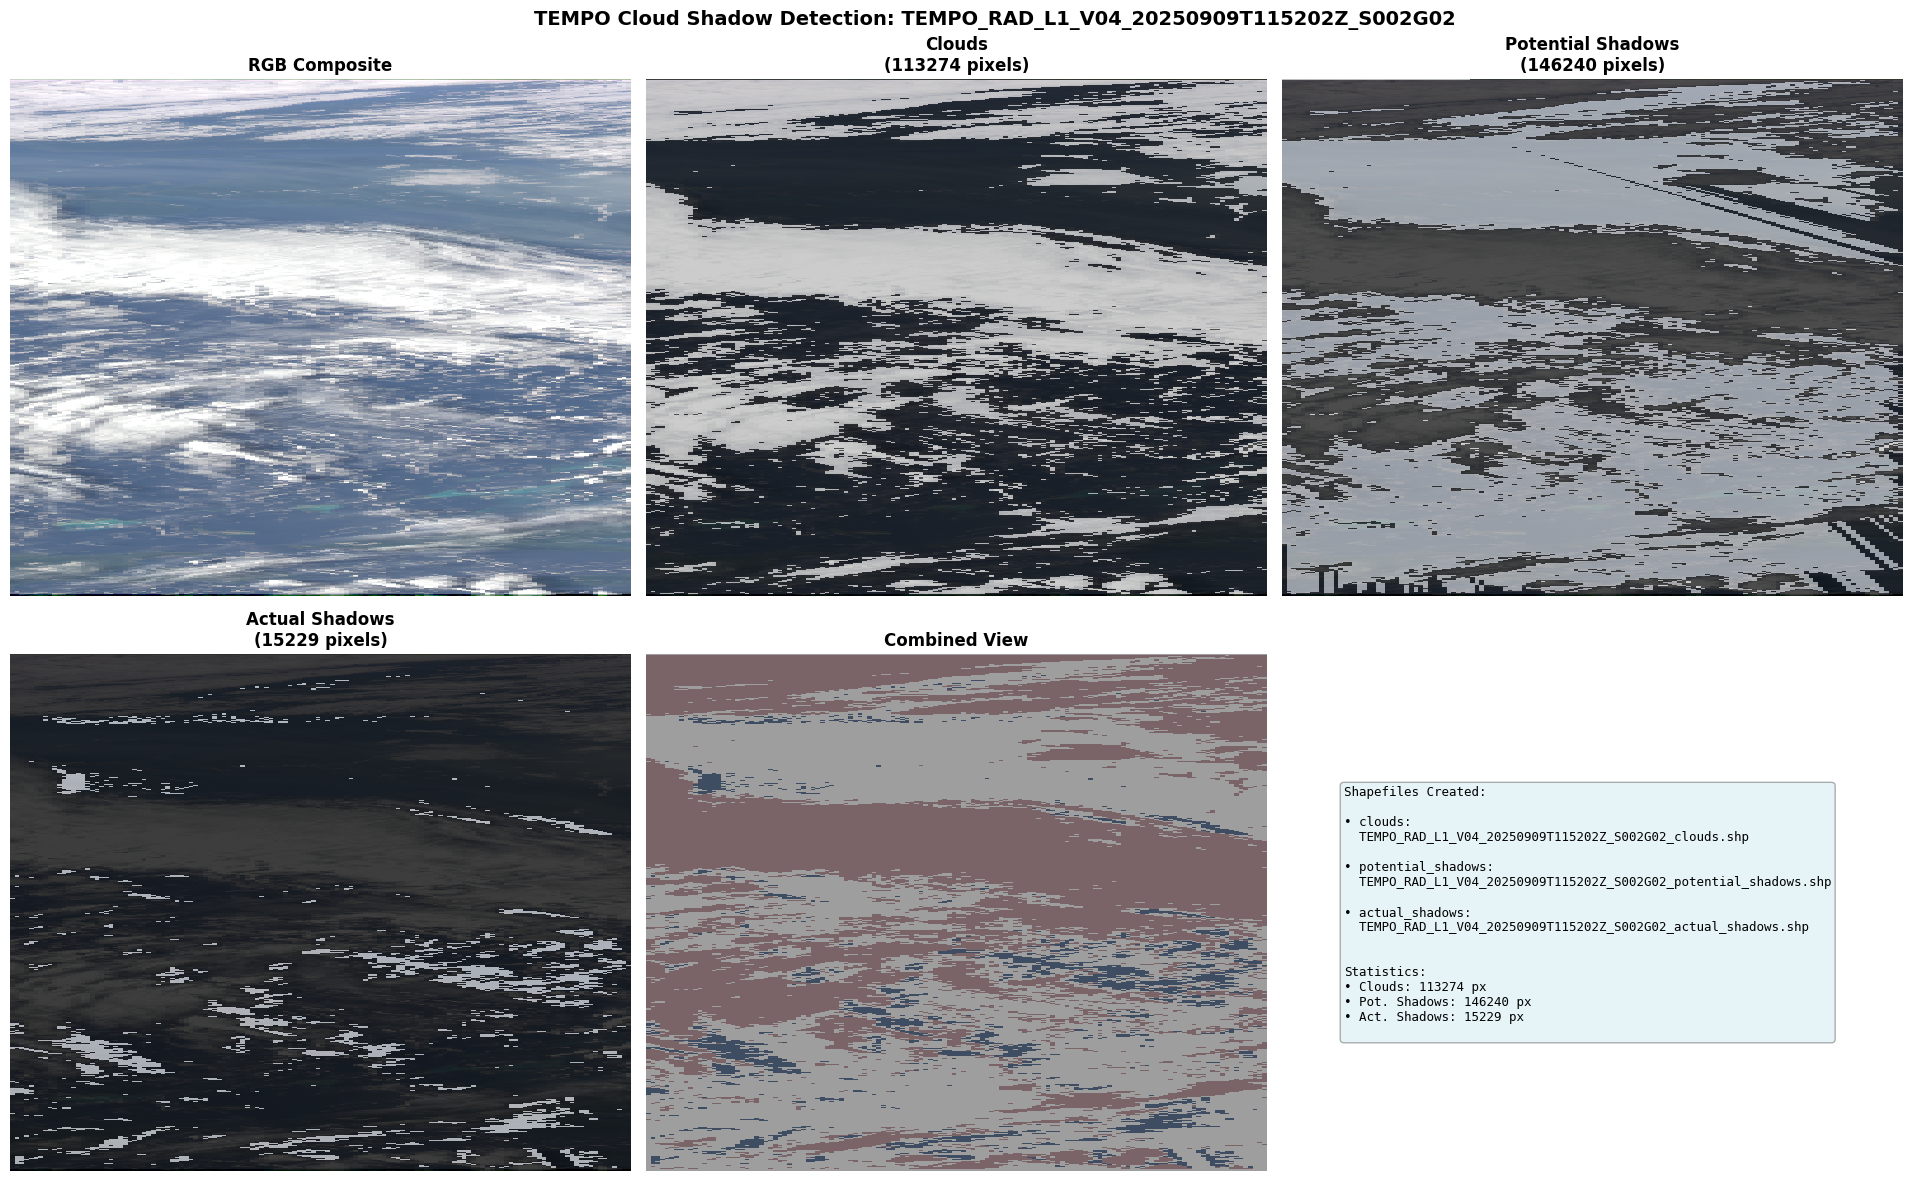


Summary Statistics:
  Cloud pixels: 113274
  Potential shadow pixels: 146240
  Actual shadow pixels: 15229
  Shadow refinement: 89.6% removed
  Shapefiles created: 3

Processing file 2/4: TEMPO_RAD_L1_V04_20250909T115842Z_S002G03.nc

Step 1: Computing potential shadows...
  Cloud fraction range: -999.000 to 1.000
  Processing 115139 cloud pixels...
    Progress: 0/115139
    Progress: 1000/115139
    Progress: 2000/115139
    Progress: 3000/115139
    Progress: 4000/115139
    Progress: 5000/115139
    Progress: 6000/115139
    Progress: 7000/115139
    Progress: 8000/115139
    Progress: 9000/115139
    Progress: 10000/115139
    Progress: 11000/115139
    Progress: 12000/115139
    Progress: 13000/115139
    Progress: 14000/115139
    Progress: 15000/115139
    Progress: 16000/115139
    Progress: 17000/115139
    Progress: 18000/115139
    Progress: 19000/115139
    Progress: 20000/115139
    Progress: 21000/115139
    Progress: 22000/115139
    Progress: 23000/115139
    Progress:

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/277729316.py:182: Runti


Visualization saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_visualization.png


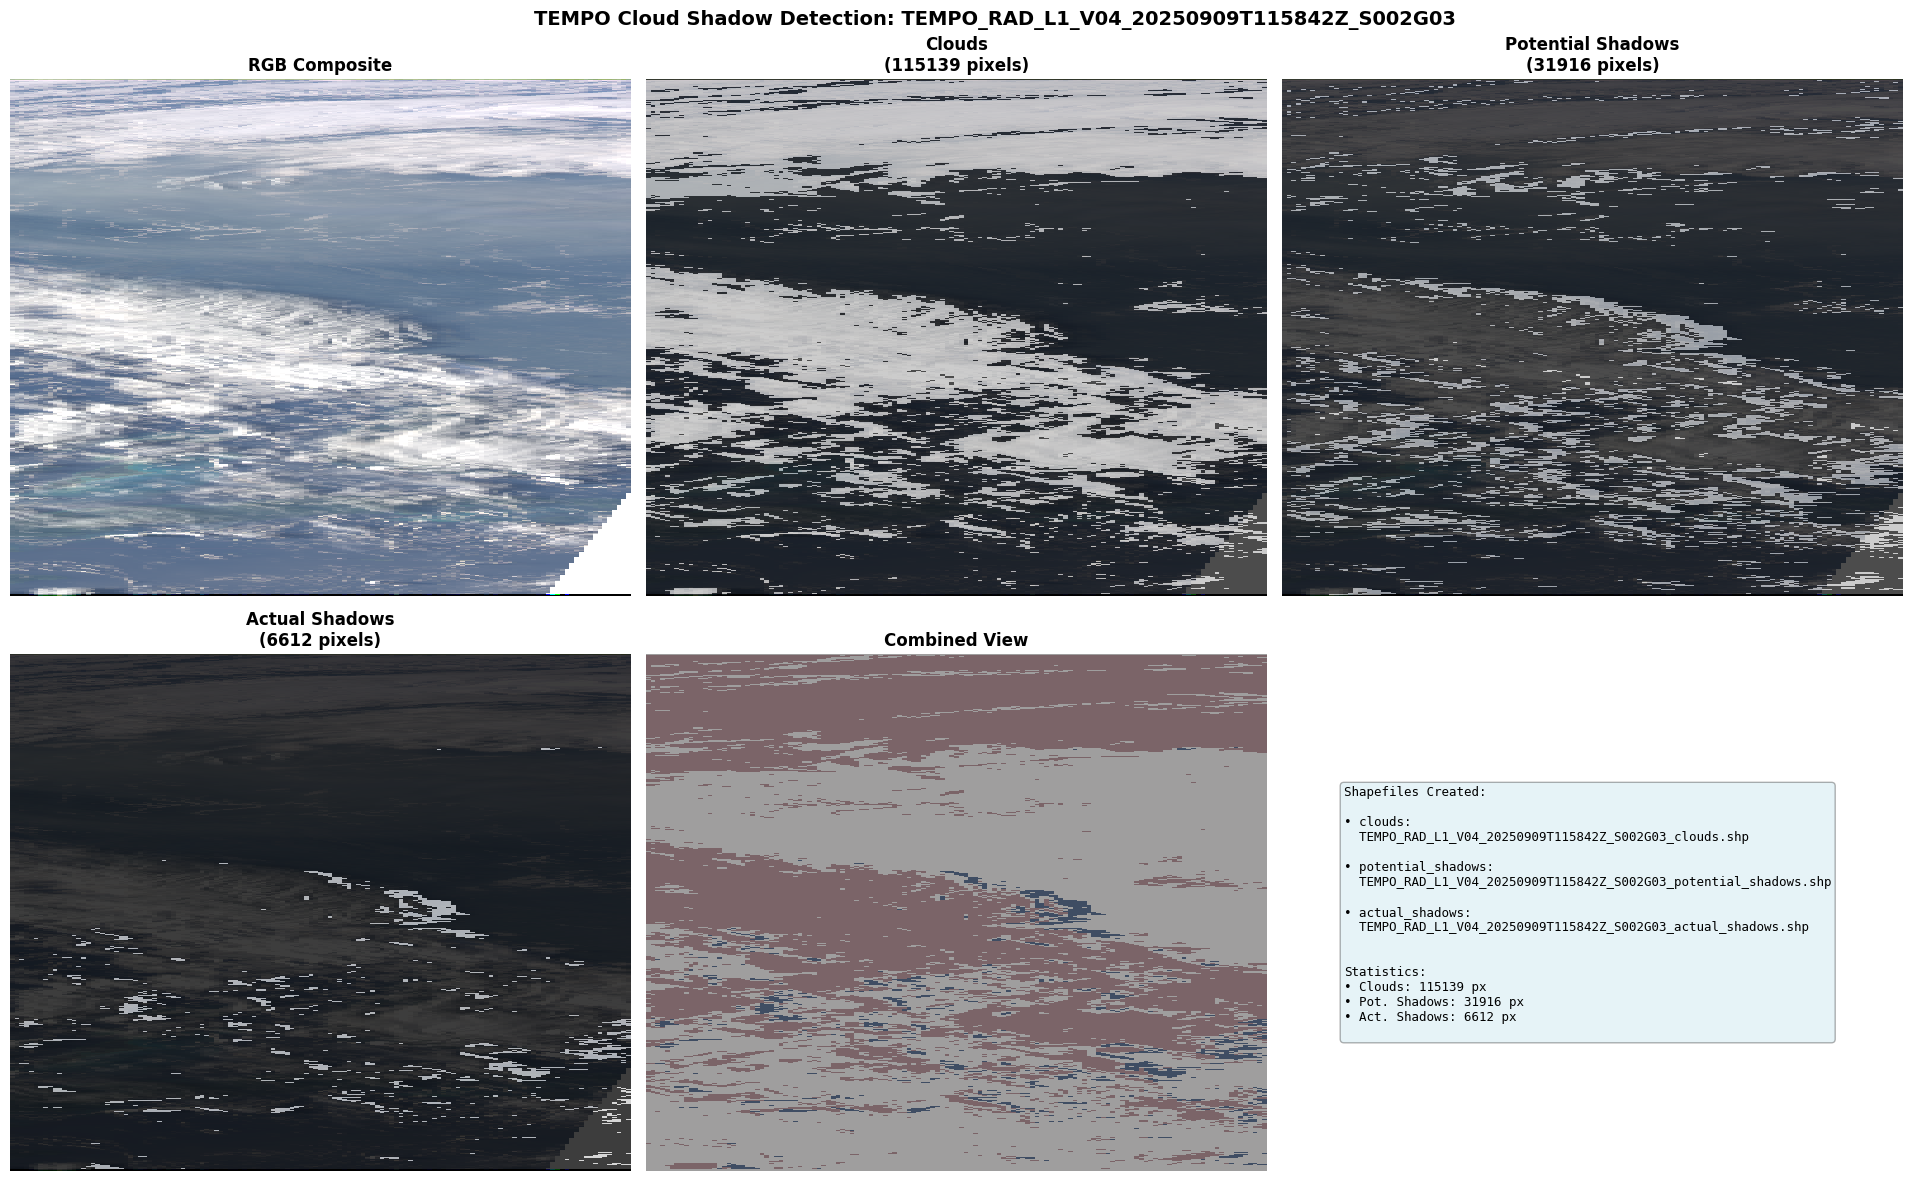


Summary Statistics:
  Cloud pixels: 115139
  Potential shadow pixels: 31916
  Actual shadow pixels: 6612
  Shadow refinement: 79.3% removed
  Shapefiles created: 3

Processing file 3/4: TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc

Step 1: Computing potential shadows...
  Cloud fraction range: -999.000 to 1.000
  Processing 104962 cloud pixels...
    Progress: 0/104962
    Progress: 1000/104962
    Progress: 2000/104962
    Progress: 3000/104962
    Progress: 4000/104962
    Progress: 5000/104962
    Progress: 6000/104962
    Progress: 7000/104962
    Progress: 8000/104962
    Progress: 9000/104962
    Progress: 10000/104962
    Progress: 11000/104962
    Progress: 12000/104962
    Progress: 13000/104962
    Progress: 14000/104962
    Progress: 15000/104962
    Progress: 16000/104962
    Progress: 17000/104962
    Progress: 18000/104962
    Progress: 19000/104962
    Progress: 20000/104962
    Progress: 21000/104962
    Progress: 22000/104962
    Progress: 23000/104962
    Progress: 2

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/277729316.py:182: Runti


Visualization saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T125205Z_S003G05_visualization.png


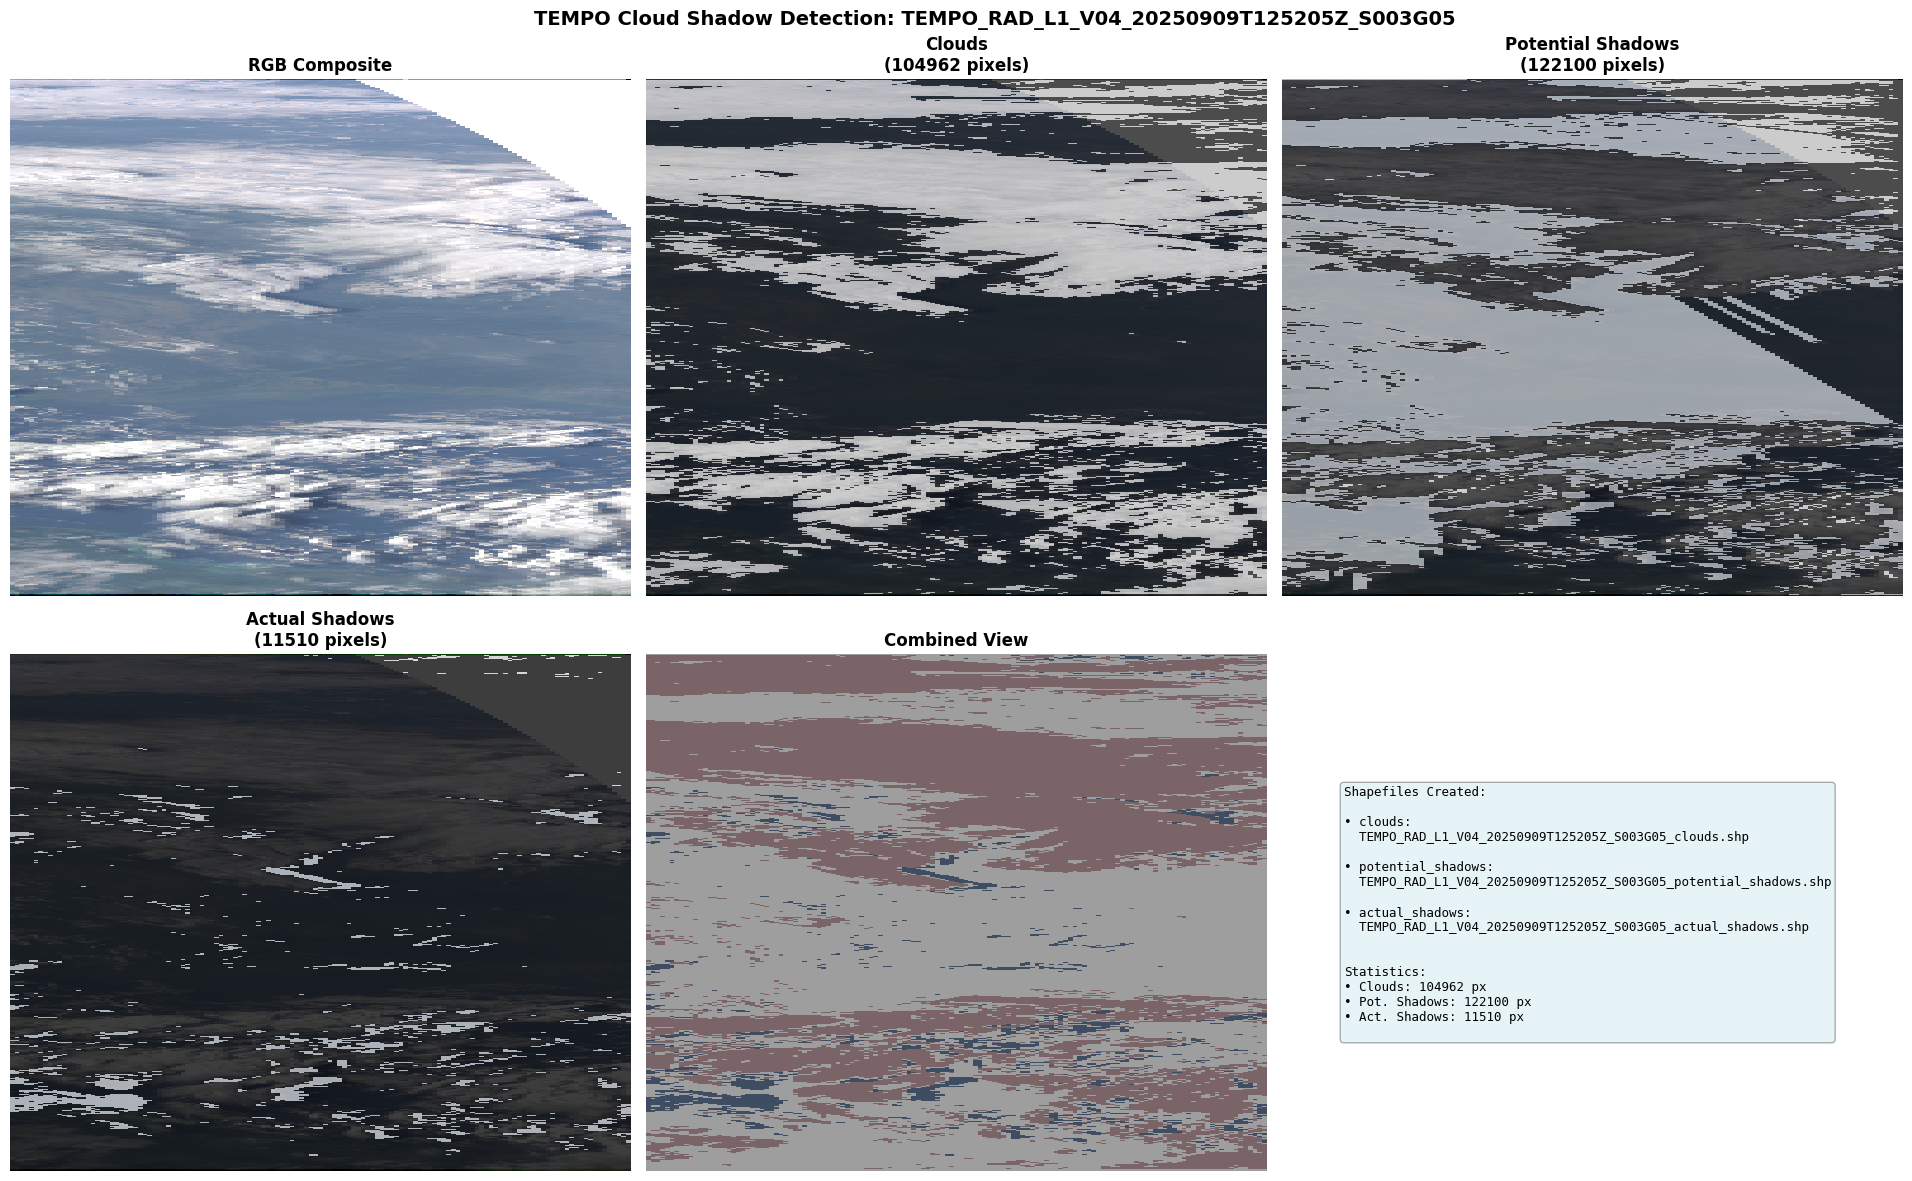


Summary Statistics:
  Cloud pixels: 104962
  Potential shadow pixels: 122100
  Actual shadow pixels: 11510
  Shadow refinement: 90.6% removed
  Shapefiles created: 3

Processing file 4/4: TEMPO_RAD_L1_V04_20250909T231218Z_S014G02.nc

Step 1: Computing potential shadows...
  Cloud fraction range: -999.000 to 1.000
  Processing 92207 cloud pixels...
    Progress: 0/92207
    Progress: 1000/92207
    Progress: 2000/92207
    Progress: 3000/92207
    Progress: 4000/92207
    Progress: 5000/92207
    Progress: 6000/92207
    Progress: 7000/92207
    Progress: 8000/92207
    Progress: 9000/92207
    Progress: 10000/92207
    Progress: 11000/92207
    Progress: 12000/92207
    Progress: 13000/92207
    Progress: 14000/92207
    Progress: 15000/92207
    Progress: 16000/92207
    Progress: 17000/92207
    Progress: 18000/92207
    Progress: 19000/92207
    Progress: 20000/92207
    Progress: 21000/92207
    Progress: 22000/92207
    Progress: 23000/92207
    Progress: 24000/92207
    Progress

/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/4141601458.py:105: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area_deg2'] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_99624/277729316.py:182: Runti

    Found 1072 polygon(s)
    Saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_actual_shadows.shp
    Total features: 1072

Creating visualization...

Visualization saved: ../experiments/output_cloudthres0.3_helen_st0.05_pressure/TEMPO_RAD_L1_V04_20250909T231218Z_S014G02_visualization.png


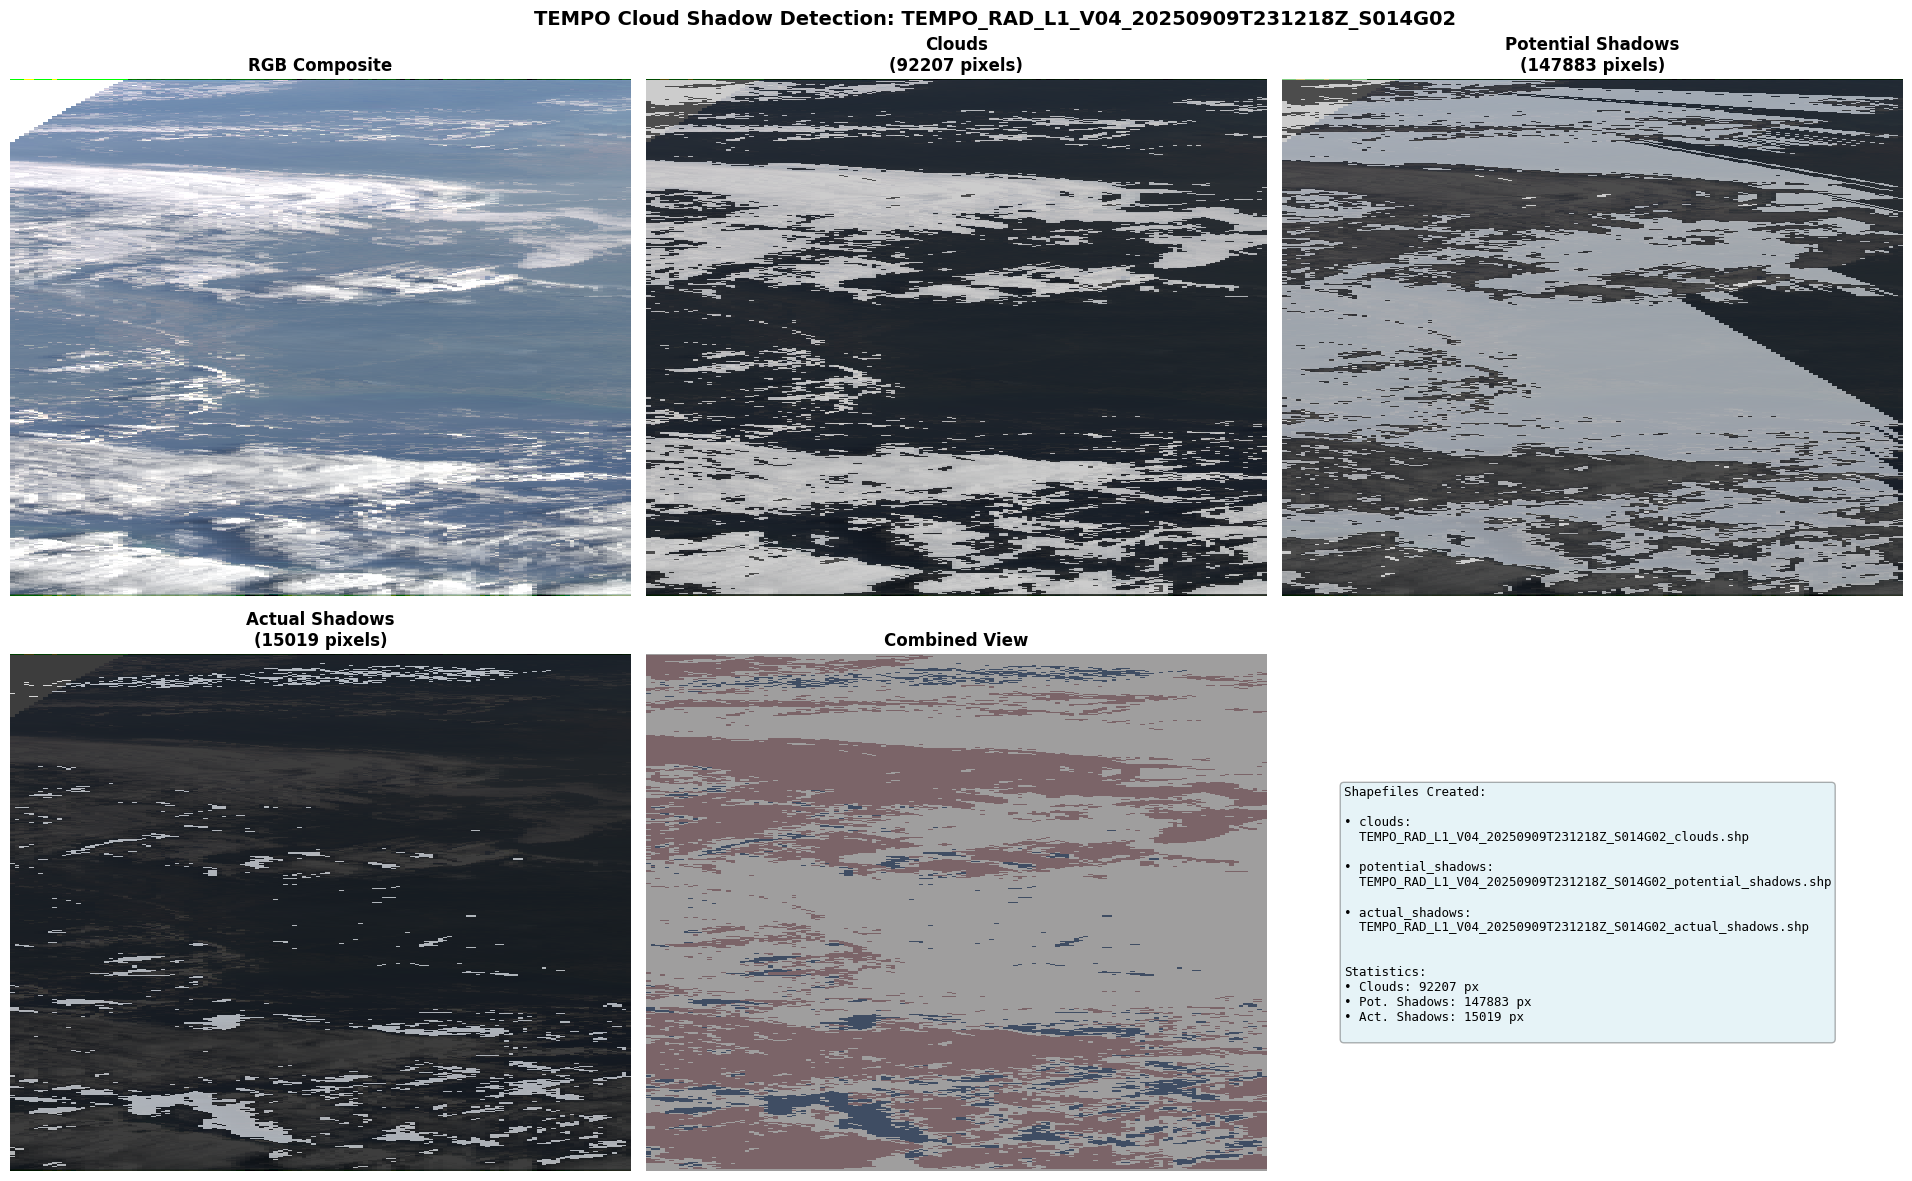


Summary Statistics:
  Cloud pixels: 92207
  Potential shadow pixels: 147883
  Actual shadow pixels: 15019
  Shadow refinement: 89.8% removed
  Shapefiles created: 3


In [5]:
import numpy as np
import geopandas as gpd
from shapely.geometry import shape
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import shapes
import h5py
import netCDF4 as nc
import os
import matplotlib.pyplot as plt


def create_shapefiles_from_masks(nc_file, l2_file, masks, output_prefix):
    """
    Create shapefiles from cloud and shadow masks using rasterio shapes
    
    Parameters:
    -----------
    nc_file : str
        Path to L1B file
    l2_file : str
        Path to L2 file
    masks : dict
        Dictionary containing 'cloud_mask', 'potential_mask', 'actual_mask'
    output_prefix : str
        Output file prefix (e.g., 'output/scene_001')
    """
    # Load geolocation from L2
    print("Loading geolocation data...")
    try:
        with h5py.File(l2_file, 'r') as f:
            lat = f['geolocation']['latitude'][:]
            lon = f['geolocation']['longitude'][:]
    except:
        with nc.Dataset(l2_file) as f:
            lat = f['geolocation']['latitude'][:]
            lon = f['geolocation']['longitude'][:]
    
    filename = os.path.basename(nc_file)
    
    # Apply transpose and flip to masks (same as RGB)
    print("Applying orientation transformation...")
    cloud_mask_oriented = np.flip(np.transpose(masks['cloud_mask'], (1, 0)), axis=0)
    potential_mask_oriented = np.flip(np.transpose(masks['potential_mask'], (1, 0)), axis=0)
    actual_mask_oriented = np.flip(np.transpose(masks['actual_mask'], (1, 0)), axis=0)
    
    # Apply same transformation to geolocation
    lon_transposed = np.flip(np.transpose(lon, (1, 0)), axis=0)
    lat_transposed = np.flip(np.transpose(lat, (1, 0)), axis=0)
    
    # Get dimensions
    height, width = cloud_mask_oriented.shape
    
    # Define geographic extent
    west = float(np.nanmin(lon_transposed))
    east = float(np.nanmax(lon_transposed))
    south = float(np.nanmin(lat_transposed))
    north = float(np.nanmax(lat_transposed))
    
    print(f"  Geographic extent: [{west:.2f}, {south:.2f}, {east:.2f}, {north:.2f}]")
    
    # Create affine transform
    transform = from_bounds(west, south, east, north, width, height)
    
    shapefile_paths = {}
    
    # Helper function to create shapefile from mask
    def mask_to_shapefile(mask, mask_type, mask_name, output_file):
        """Convert binary mask to shapefile using rasterio"""
        print(f"\n  Creating {mask_name} shapefile...")
        
        # Convert boolean to int32
        mask_int = mask.astype(np.int32)
        
        # Handle NaN/invalid values
        mask_int = np.where(np.isnan(mask_int), 0, mask_int)
        
        # Extract shapes from the mask
        # shapes() returns (geometry, value) tuples
        results = list(shapes(mask_int, mask=(mask_int == 1), transform=transform))
        
        if len(results) == 0:
            print(f"    WARNING: No features found for {mask_name}")
            return None
        
        print(f"    Found {len(results)} polygon(s)")
        
        # Create lists of geometries and attributes
        geometries = []
        properties = []
        
        for geom, value in results:
            geometries.append(shape(geom))
            properties.append({
                'type': mask_type,
                'name': mask_name,
                'value': int(value),
                'source': filename
            })
        
        # Create GeoDataFrame
        gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs='EPSG:4326')
        
        # Add area calculation (in square degrees)
        gdf['area_deg2'] = gdf.geometry.area
        
        # Save as shapefile
        gdf.to_file(output_file)
        print(f"    Saved: {output_file}")
        print(f"    Total features: {len(gdf)}")
        
        return output_file
    
    # 1. Cloud mask shapefile
    print("\n1. Processing cloud mask...")
    cloud_shp = f"{output_prefix}_clouds.shp"
    result = mask_to_shapefile(
        cloud_mask_oriented, 'cloud', 'Cloud', cloud_shp
    )
    if result:
        shapefile_paths['clouds'] = result
    
    # 2. Potential shadow shapefile
    print("\n2. Processing potential shadows...")
    potential_shp = f"{output_prefix}_potential_shadows.shp"
    result = mask_to_shapefile(
        potential_mask_oriented, 'potential_shadow', 'Potential Shadow', potential_shp
    )
    if result:
        shapefile_paths['potential_shadows'] = result
    
    # 3. Actual shadow shapefile
    print("\n3. Processing actual shadows...")
    actual_shp = f"{output_prefix}_actual_shadows.shp"
    result = mask_to_shapefile(
        actual_mask_oriented, 'actual_shadow', 'Actual Shadow', actual_shp
    )
    if result:
        shapefile_paths['actual_shadows'] = result
    return shapefile_paths


def create_shadow_detection_pipeline_with_shapefiles(nc_files, l2_files,
                                                      output_dir='shapefile_output',
                                                      band='band_290_490_nm',
                                                      cloud_threshold=0.05,
                                                      apply_gamma=True,
                                                      refinement='lamb', 
                                                      shadow_threshold=0.05):
    """
    Complete pipeline with shapefile export using rasterio
    
    Parameters:
    -----------
    nc_files : list
        List of L1B files
    l2_files : list
        List of L2 files
    output_dir : str
        Output directory for shapefiles
    band : str
        Band name
    cloud_threshold : float
        Cloud fraction threshold
    apply_gamma : bool
        Apply gamma correction to RGB
    """
    os.makedirs(output_dir, exist_ok=True)
    
    results = []
    
    for idx, (nc_file, l2_file) in enumerate(zip(nc_files, l2_files)):
        print(f"\n{'='*80}")
        print(f"Processing file {idx+1}/{len(nc_files)}: {os.path.basename(nc_file)}")
        print('='*80)
        
        # Run shadow detection
        print("\nStep 1: Computing potential shadows...")
        potential_mask, cloud_mask, cloud_fraction = compute_potential_shadow_mask(
            nc_file, l2_file, band, cloud_threshold
        )

        actual_mask = (cloud_fraction > -999) & (cloud_fraction < shadow_threshold)
        actual_mask = actual_mask * potential_mask.astype('uint')
    
        # Prepare masks dictionary
        masks = {
            'cloud_mask': cloud_mask,
            'potential_mask': potential_mask,
            'actual_mask': actual_mask
        }
        
        # Create output prefix
        base_name = os.path.splitext(os.path.basename(nc_file))[0]
        output_prefix = os.path.join(output_dir, base_name)
        
        # Create shapefiles
        print("\n" + "="*80)
        print("Creating shapefiles...")
        print("="*80)
        
        shapefile_paths = create_shapefiles_from_masks(
            nc_file, l2_file, masks, output_prefix
        )
        
        # Visualization
        print("\nCreating visualization...")
        rgb = prepare_rgb_for_visualization(nc_file, band, apply_gamma)
        
        # Apply same orientation to masks for visualization
        potential_mask_vis = np.flip(np.transpose(potential_mask, (1, 0)), axis=0)
        actual_mask_vis = np.flip(np.transpose(actual_mask, (1, 0)), axis=0)
        cloud_mask_vis = np.flip(np.transpose(cloud_mask, (1, 0)), axis=0)
        
        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        # Row 1
        axes[0, 0].pcolormesh(rgb)
        axes[0, 0].set_title('RGB Composite', fontsize=12, fontweight='bold')
        axes[0, 0].axis('off')
        
        axes[0, 1].pcolormesh(rgb * 0.6)
        axes[0, 1].pcolormesh(cloud_mask_vis, cmap="Greys_r", alpha=0.5)
        axes[0, 1].set_title(f'Clouds\n({np.sum(cloud_mask)} pixels)', 
                            fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        
        axes[0, 2].pcolormesh(rgb * 0.6)
        axes[0, 2].pcolormesh(potential_mask_vis, cmap="Greys_r", alpha=0.5)
        axes[0, 2].set_title(f'Potential Shadows\n({np.sum(potential_mask)} pixels)',
                            fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')
        
        # Row 2
        axes[1, 0].pcolormesh(rgb * 0.6)
        axes[1, 0].pcolormesh(actual_mask_vis, cmap="Greys_r", alpha=0.6)
        axes[1, 0].set_title(f'Actual Shadows\n({np.sum(actual_mask)} pixels)',
                            fontsize=12, fontweight='bold')
        axes[1, 0].axis('off')
        
        combined = rgb.copy().astype(float) * 0.5
        axes[1, 1].pcolormesh(combined.astype(np.uint8))
        axes[1, 1].pcolormesh(cloud_mask_vis, cmap='Reds', alpha=0.4)
        axes[1, 1].pcolormesh(actual_mask_vis, cmap='Blues', alpha=0.4)
        axes[1, 1].set_title('Combined View', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')
        
        # Show shapefile info
        axes[1, 2].axis('off')
        info_text = "Shapefiles Created:\n\n"
        for key, path in shapefile_paths.items():
            info_text += f"• {key}:\n  {os.path.basename(path)}\n\n"
        
        # Add statistics
        info_text += f"\nStatistics:\n"
        info_text += f"• Clouds: {np.sum(cloud_mask)} px\n"
        info_text += f"• Pot. Shadows: {np.sum(potential_mask)} px\n"
        info_text += f"• Act. Shadows: {np.sum(actual_mask)} px\n"
        
        axes[1, 2].text(0.1, 0.5, info_text, fontsize=9,
                       verticalalignment='center', family='monospace',
                       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
        
        plt.suptitle(f'TEMPO Cloud Shadow Detection: {base_name}',
                    fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        
        # Save figure
        fig_path = f"{output_prefix}_visualization.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"\nVisualization saved: {fig_path}")
        
        plt.show()
        
        # Statistics
        n_clouds = np.sum(cloud_mask)
        n_potential = np.sum(potential_mask)
        n_actual = np.sum(actual_mask)
        
        print(f"\n{'='*80}")
        print("Summary Statistics:")
        print('='*80)
        print(f"  Cloud pixels: {n_clouds}")
        print(f"  Potential shadow pixels: {n_potential}")
        print(f"  Actual shadow pixels: {n_actual}")
        print(f"  Shadow refinement: {(1 - n_actual/max(n_potential, 1))*100:.1f}% removed")
        print(f"  Shapefiles created: {len(shapefile_paths)}")
        
        results.append({
            'file': nc_file,
            'masks': masks,
            'shapefile_paths': shapefile_paths,
            'visualization': fig_path,
            'stats': {
                'n_clouds': n_clouds,
                'n_potential_shadows': n_potential,
                'n_actual_shadows': n_actual
            }
        })
    
    return results


results = create_shadow_detection_pipeline_with_shapefiles(
        nc_files, #[i:i+1],  # Process first 3 files
        l2_files, #[i:i+1],
        output_dir=output_dir,
        band=band,
        refinement=refinement,
        cloud_threshold=cloud_threshold,
        shadow_threshold=shadow_threshold,
        apply_gamma=True,
    )